# Conjugation: Bond Rotation in Butadiene

To understand the effect of conjugation it is useful to explore the conformational energy profile for rotating the central C-C bond in butane and butadiene. this notebook will present the profile for **butane**.

We can calculate the energy for different conformations of butane using programs that perform quantum mechanical calculations. I have no idea what is happening under the hood, but this python notebook will document my methods and then others can correct my errors easily while judging me harshly. I will be using the ***Psi4*** computational chemistry package. It is freely available as a *Python* module and so it is very convenient to use in a notebook like this one.

## Setting Up

```{note}
:class: dropdown
This notebook contains the instructions and code to optimize the structure and calculate the energy for a set of butane molecules with fixed torsional angles at the central C-C bond. the data is saved in csv and binary files for use in the next notebook that will use the data for extracting useful information. I am doing this so that the two operations: data creation and data analuysis are separated. The calculation here took ten minutes on my computer. So you can start with the data rather than repeating the expensive calculation if you wish
```

First I am going to set up the calculation by setting the variables in the code block below. You will see that I choose the name of the job (`basename`: this will be used to name the log and result files) and an extra name to add to that name as I try multiple runs (`runname`). I also set up information for what angles to set for the bond rotation(`start_angle`, `end_angle`, and `step_size`). the most important data is the structural data. I must describe the positions of atoms for the calculation. I set a text block in a variable called `butane_template` to hold the structural info. The format does not matter, just know that the data describes the initial structure.  the `{phi}` placeholder will be replaced with the chosen bond angle in the calculations that follow.

If your interested, the structural data is presented as a z-matrix. this is a format that describes the positions of atoms relative to each other. the firest line states the charge and electronic state as 0 charge and a singlet electronic state (singlet means all electrons are paired). the following lines describe the atoms. the Z-matric copuld be describes as follows...

```
Atom #1 is carbon;
Atom #2 is carbon and it is 1.34 Angstroms from atom #1.
Atom #3 is carbon and it is 1.46 Angstroms from atom #2 and at an angle of 122 degrees from the 1,2 bond 
Atom #4 is carbon and it is 1.34 Angstroms from atom #3 and at an angle of 122 degrees from the 2,3 bond and at a torsional angle of {phi} from the plane defined by atoms 1,2 and 3.
Atom #5 is hydrogen and it is 1.09 Angstroms from atom #1 and at an angle of 121 degrees from the 1,2 bond and at a torsional angle of 181 degrees from the plane defined by atoms 1,2 and 3.
etc.
```

We now have everything set up. We will need only to change this setup infromation when we switch to butadiene in the next notebook.

In [1]:
import psi4
import numpy as np
import pandas as pd
import sys
from contextlib import redirect_stdout
from contextlib import redirect_stderr
import time

basename = "butadiene_scan" # Base name for log files and output CSV file. This will be combined with the 'runname' variable to create unique file names for each run.
runname = "hf-6-31G-previous" # You can change this to keep track of different runs with different settings. This will be used in the log file names and the output CSV file name.

method = "hf/6-31G*" # You can change this to use a different level of theory and basis set. For example, "mp2/6-31G*", "b3lyp/6-31G*", etc.

start_angle = 0 # Starting dihedral angle in degrees
end_angle = 180 # Ending dihedral angle in degrees
step_size = 5 # Step size for dihedral angle in degrees

# Define base butane geometry (Z-matrix for easy dihedral manipulation)
# I added 1 to all torsion angles to avoid symmetry locks in the structure. This is a common trick to break 
#    symmetry and allow the optimization to proceed without getting stuck in a high-symmetry point.
template = """

0 1
C
C 1 1.34
C 2 1.46 1 122.0
C 3 1.34 2 122.0 1 {phi}
H 1 1.09 2 121.0 3 181.0
H 1 1.09 2 121.0 3 1.0
H 2 1.09 1 121.0 3 181.0
H 3 1.09 4 121.0 2 181.0
H 4 1.09 3 121.0 2 181.0
H 4 1.09 3 121.0 2 1.0
"""


## Running *Psi4*

The code below will run the job. It will use the structure data in `template` and substitute the `{psi}` with the value for the torsion angle. The code establishes the settings for the calculation, inputs the molecular geometry and then runs a structural optimization job to find the lowest energy structure for the given tortional angle. the torsion angle for the central C-C bond is locked but all other bond distances, bond angles and torsion angles can change until the lowest energy structure is found.

```{note}
:class: dropdown
This job will take more about 5 minutes to run. There is data from a previous run available. it is much faster than in the case of butane because it has fewer atoms (10 instead of 14). the Hartree-Fock method used in the calculations scales at $n^6$. this calculation should take about one eigth of the effort, and that is approximately true in this case. The molecule is more rigid and converged easily in the optimization algorthm so I did not have to use any of the optional tricks to help it converge.
```

In [3]:
import psi4
import numpy as np
import pandas as pd
import sys
from contextlib import redirect_stdout
from contextlib import redirect_stderr
import time

# Set Psi4 options
psi4.core.set_output_file(f"{basename}_{runname}.log", False) # True: append logs; False: overwrite logs
psi4.set_memory('2 GB')
psi4.set_num_threads(4) # Adjust based on your CPU cores; 1 for single-threaded, more for parallel
psi4.set_options({
    'print': 1,         # 0 for no output, 1 for minimal output, 2 for detailed output. Needs to be set to 1 or greater for optking to work properly.
    'reference': 'rhf', # 'uhf', 'rhf', 'rohf'
    'scf_type': 'df',   # density fitting for faster SCF. Other options are 'pk' (default), 'direct', 'outofcore' and more
    'optking__frozen_dihedral': '1 2 3 4',
# efforts to solve convergence problems. Try some of these if the calculations fail.
#    'optking__g_convergence': 'gau_tight',  # Use tight convergence for better accuracy in geometry optimization. This is optional but can help ensure that the optimized geometries are well-converged, especially when scanning over a range of dihedral angles where the energy landscape can be complex.
#    'geom_maxiter': 200, # Increase maximum iterations for geometry optimization to ensure convergence, especially for challenging angles. This is optional but can help prevent premature termination of the optimization.})
#    'optking__max_force_g_convergence': 0.1, # Increase maximum force threshold for geometry optimization to allow for more flexibility in the optimization process, especially when scanning over a range of dihedral angles where the energy landscape can be complex. This is optional but can help ensure that the optimization can proceed even if the forces are relatively large at certain angles.})
#    'full_hess_every': 5, # Perform a full Hessian calculation every 5 steps to improve convergence, especially for challenging angles. This is optional but can help ensure that the optimization has accurate curvature information to guide the optimization process.})
#    'opt_coordinates': 'both' # Optimize in both Cartesian and internal coordinates to improve convergence, especially for challenging angles. This is optional but can help ensure that the optimization can find the optimal geometry more effectively.
    })

# define message for header of each optimization run in the loop. This will be printed to the stderr file for each angle, so we can easily see where each optimization starts in the log.
dihedral_print_message = """

--------------------------------------------------
Starting optimization for dihedral angle: {phi:.1f} degrees
--------------------------------------------------

"""

# Define scan range (0 to 360 degrees)
angles = np.arange(start_angle, end_angle + step_size, step_size) # Generate array of dihedral angles from start to end with the specified step size
energies = []
molecules = []
wavefunctions = []

globalstart = time.time()
with open(f"{basename}_stderr_{runname}.txt", "w") as f: # These with statements redirect the standard error output (which is where Psi4 writes its logs) to a file called "stderr.txt". This allows us to capture the verbose output from Psi4 without cluttering the console.
    with redirect_stderr(f):

        # Loop over angles and perform calculations for butane at each angle
        for phi in angles:
            sys.stderr.write(dihedral_print_message.format(phi=phi)) # Print to a file for stderr. verbose output from Psi4 will be written to this file.

            print(f"Calculating for dihedral = {phi:.1f} deg")
        
            # Create molecule with current dihedral
            mol = psi4.geometry(template.format(phi=phi))

#           dihedral_string = f"1 2 3 4 {phi}.0 {phi+0.05}"
#           psi4.set_options({"optking__ranged_dihedral": f"{dihedral_string}",
#                             "optking__g_convergence": "gau_tight", # Use tight convergence for better accuracy in geometry optimization. This is optional but can help ensure that the optimized geometries are well-converged, especially when scanning over a range of dihedral angles where the energy landscape can be complex.})
#                               })
            # Compute energy (with structural optimization)
            start = time.time()

            ###############################
            # This is where Psi4 is used. This will use the structure established from 'butane_template' with the 
            #     angle 'phi' set to a value from the list 'angles'. The 'optimize' function will perform a geometry 
            #     optimization at the specified level of theory (SCF in this case) while keeping the specified 
            #     dihedral angle frozen. 'hf' is the level of theory (Hartree-Fock). You can change this to 'mp2', 
            #     'ccsd', 'b3lyp', etc. for more accurate calculations, but it will take longer.
            ###############################
            energy = psi4.optimize(method, molecule=mol, return_wfn=False)
            ###############################
            # End of Psi4 calculation. Everything else is just setup and timing.
            ###############################

            energies.append(energy) # The final optimized energy from the calculation is stored in the 'energies' list.
            wavefunctions.append(wfn) # The wavefunction from the calculation is stored in the 'wavefunctions' list.

            end = time.time()
            print(f"Time for dihedral optimization {phi:.1f} deg: {end - start:.2f} seconds")

            mol = psi4.core.get_active_molecule() # After the optimization, we retrieve the optimized molecule using 'get_active_molecule()'. This allows us to store the optimized geometry for each angle in the 'molecules' list. We do this after the optimization so that we have the final optimized structure for each dihedral angle, rather than just the initial structure that we started with for each angle.            
            molecules.append(mol)


globalend = time.time()
print(f"Total time for scan: {globalend - globalstart:.2f} seconds")

# Get relative energies (kJ/mol)
energies_array = np.array(energies)                    # Convert list to numpy array for easier manipulation
energies_array = energies_array - energies_array.min() # Set minimum energy to zero
energies_array = energies_array * 627.509 * 4.184      # ConvertHartree to kJ/mol

print("\nScan complete.")


Calculating for dihedral = 0.0 deg
Optimizer: Optimization complete!
Time for dihedral optimization 0.0 deg: 4.46 seconds
Calculating for dihedral = 5.0 deg
Optimizer: Optimization complete!
Time for dihedral optimization 5.0 deg: 4.38 seconds
Calculating for dihedral = 10.0 deg
Optimizer: Optimization complete!
Time for dihedral optimization 10.0 deg: 4.31 seconds
Calculating for dihedral = 15.0 deg
Optimizer: Optimization complete!
Time for dihedral optimization 15.0 deg: 4.40 seconds
Calculating for dihedral = 20.0 deg
Optimizer: Optimization complete!
Time for dihedral optimization 20.0 deg: 4.29 seconds
Calculating for dihedral = 25.0 deg
Optimizer: Optimization complete!
Time for dihedral optimization 25.0 deg: 4.34 seconds
Calculating for dihedral = 30.0 deg
Optimizer: Optimization complete!
Time for dihedral optimization 30.0 deg: 3.75 seconds
Calculating for dihedral = 35.0 deg
Optimizer: Optimization complete!
Time for dihedral optimization 35.0 deg: 4.37 seconds
Calculating 

## Store the Data
the code below will take the vaiable that contain the following information and store it so that we can retrieve the data later from files rather than repeat a lengthy calculation.

The angle, relative energy (kJ/mole) and calculated HF energy (Hartrees) will be strored in a csv file.

The list of optimized molecular structures will be converted to strings of Z-matrix internal coordinates and xyz cartessian coordinates and these will also be included in the csv file above. 

The list of wavefunction data for each structure (Psi4 objects) can be stored as separate files of numpy arrays using the `.to_file()` method available to Psi4 wavefunction objects.


In [5]:
##################################################
# SAVE DATA
##################################################

# Save binary objects as pickle files

num = []
zmat = []
xyz = []

items = zip(molecules, wavefunctions, range(len(molecules)))
for m, w, n in items:
    num.append(n)
    zmat.append(m.create_psi4_string_from_molecule())
    xyz.append(m.save_string_xyz())
#    w.to_file(f"wfn_data/{basename}_{runname}_wavefunction_{n}.wfn")

# make dataframe from angles and energies
df = pd.DataFrame({
    'Number': num,
    'Dihedral Angle (deg)': angles,
    'Energy (kJ/mol)': energies_array,
    'Energy (Ha)': energies,
    'zmatrix': zmat,
    'xyz': xyz,
    })

# Save angles and data to CSV
df.to_csv(f"{basename}_{runname}.csv", index=False)


## Plot the Data

This plot is also made in the data processing notebook that follows this one. It is here as a quick check that the calculation produced sensible results.

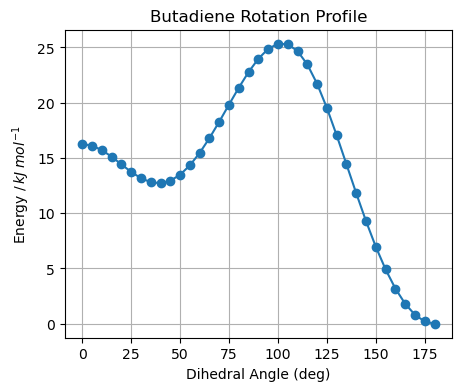

In [6]:
import matplotlib.pyplot as plt

styles_location = "../../../styles/"
plt.rcParamsDefault
#plt.style.use(styles_location + "tufte.mplstyle")        
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  

df = pd.read_csv(f"{basename}_{runname}.csv")

ax.plot(df["Dihedral Angle (deg)"], df["Energy (kJ/mol)"], marker='o')
ax.set_xlabel("Dihedral Angle (deg)")
ax.set_ylabel(r"Energy $/\,kJ\; mol^{-1}$")
ax.set_title("Butadiene Rotation Profile")
plt.grid()
plt.show()




In [7]:
import py3Dmol
import ipywidgets as widgets
from IPython.display import display
from ipywidgets import interact, interactive, fixed


# --- Convert Psi4 molecules to XYZ strings ---
xyz_strings = []       
for mol in molecules:
    temp = mol.save_string_xyz()
    lines = temp.splitlines()
    xyz_string = "\n".join(["10", ""] + lines[1:])
    xyz_strings.append(xyz_string)

#print(xyz_strings[0]) # Print the first XYZ string to check the format. This should show the number of atoms, a blank line, and then the atomic symbols and coordinates for each atom in the molecule.
print("test")

# --- Viewer function ---


def show_molecule(i):
    xyz = xyz_strings[i]
    energy = energies_array[i]
    print(f"Structure: {i}, Energy: {energy:.2f} kJ/mol")

    view = py3Dmol.view(
        width=500,
        height=400,
    )
    view.addModel(xyz, 'xyz')
    view.setStyle({'stick': {}, 'sphere': {'scale': 0.3}})
    view.setBackgroundColor ('#f9f9f9')

    view.setViewStyle({
        'style':'outline',
        'color':'black',
        'width':0.03,
    })
#    # Add title with energy
#    view.addLabel(
#        f"Index: {i}\nEnergy: {energy:.6f} kJ/mol",
#        {'position': {'x': 0, 'y': 0, 'z': 0},
#         'backgroundColor': 'white',
#         'fontColor': 'black'}
#    )


    #view.zoomTo()
    return view.show()

# --- Slider widget ---
slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(molecules)-1,
    step=1,
    description='Structure',
    continuous_update=False
)

## --- Link slider to viewer ---
#interactive_view = widgets.interactive_output(
#    show_molecule,
#    {'i': slider}
#)
#
## --- Display ---
#display(slider, interactive_view)

interact(show_molecule, i=widgets.IntSlider(min=0,max=len(xyz_strings)-1, step=1))


test


interactive(children=(IntSlider(value=0, description='i', max=36), Output()), _dom_classes=('widget-interact',…

<function __main__.show_molecule(i)>

In [6]:
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem
from ipywidgets import interact, interactive, fixed


def drawit(m,p,confId=-1):
    mb = Chem.MolToMolBlock(m,confId=confId)
    p.removeAllModels()
    p.addModel(mb,'sdf')
    p.setStyle({'stick':{}})
    p.setBackgroundColor('0xeeeeee')
    p.zoomTo()
    return p.show()

m = Chem.MolFromSmiles(r'COc1ccc2[nH]c([S@@+]([O-])Cc3ncc(C)c(OC)c3C)nc2c1') # esomeprazole
m = Chem.AddHs(m)
AllChem.EmbedMultipleConfs(m,numConfs=10,randomSeed=0xf00d,useExpTorsionAnglePrefs=True,\
                       useBasicKnowledge=True)
# align to one of the ring systems:
AllChem.AlignMolConformers(m,m.GetSubstructMatch(Chem.MolFromSmarts('c1[nH]c2ccccc2n1')))
# now construct the view and interactive widget:
p = py3Dmol.view(width=400,height=400)
interact(drawit, m=fixed(m),p=fixed(p),confId=(0,m.GetNumConformers()-1));

[20:40:39] UFFTYPER: Unrecognized charge state for atom: 8


interactive(children=(IntSlider(value=0, description='confId', max=9), Output()), _dom_classes=('widget-intera…